## Библиотеки

In [ ]:
#
from pathlib import Path

#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

#
random_id = 123

## Обзор

In [85]:
dataset_path = Path.cwd().parent / 'back_dataset' / 'telecom_churn_clean.csv'
print(dataset_path)

d:\PycharmProjects\urfu_mlops\back_dataset\telecom_churn_clean.csv


In [86]:
#Загружаем датасет
df = pd.read_csv(r'D:\PycharmProjects\urfu_mlops\back_dataset\telecom_churn_clean.csv')
df = df.drop(df.columns[0], axis=1)
df.sample(10)

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
992,45,510,0,1,26,91.7,104,15.59,150.6,119,12.80,63.3,103,2.85,7.7,5,2.08,1,0
1508,93,408,0,0,0,152.4,74,25.91,274.6,88,23.34,252.2,120,11.35,6.6,5,1.78,3,0
2564,16,510,0,0,0,153.2,65,26.04,229.7,90,19.52,148.2,94,6.67,10.7,8,2.89,1,0
2744,33,408,0,0,0,159.5,115,27.12,195.4,118,16.61,102.4,86,4.61,7.1,7,1.92,1,0
1521,103,415,0,0,0,173.5,83,29.50,244.3,65,20.77,221.6,66,9.97,9.7,2,2.62,3,0
1274,111,510,0,0,0,176.4,62,29.99,201.0,124,17.09,150.4,138,6.77,11.2,2,3.02,0,0
2969,116,408,0,0,0,110.9,54,18.85,213.4,82,18.14,186.2,116,8.38,7.9,2,2.13,2,0
2457,130,415,0,1,45,174.5,120,29.67,217.5,95,18.49,220.3,67,9.91,12.2,2,3.29,1,0
2745,61,408,0,1,40,105.0,78,17.85,180.6,100,15.35,174.1,115,7.83,10.2,2,2.75,2,1
2771,67,510,0,1,31,175.2,68,29.78,199.2,73,16.93,219.8,99,9.89,13.2,6,3.56,1,0


In [87]:
X = df.drop(['churn'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y, # сохранить распределение данных
    random_state=123
)

In [88]:
df.nunique()

account_length             212
area_code                    3
international_plan           2
voice_mail_plan              2
number_vmail_messages       46
total_day_minutes         1667
total_day_calls            119
total_day_charge          1667
total_eve_minutes         1611
total_eve_calls            123
total_eve_charge          1440
total_night_minutes       1591
total_night_calls          120
total_night_charge         933
total_intl_minutes         162
total_intl_calls            21
total_intl_charge          162
customer_service_calls      10
churn                        2
dtype: int64

In [89]:
# scaler = preprocessing.StandardScaler().set_output(transform="pandas")
# scaler.fit(X_train)

# X_train = scaler.transform(X_train)
# X_test = scaler.transform(X_test)

X_test.sample(5)

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls
872,149,510,0,1,43,206.7,79,35.14,174.6,122,14.84,241.5,80,10.87,10.9,3,2.94,1
1339,90,415,1,0,0,148.2,96,25.19,220.4,111,18.73,134.2,97,6.04,9.2,1,2.48,4
1927,110,510,0,0,0,188.0,127,31.96,90.5,118,7.69,150.3,64,6.76,15.3,3,4.13,3
1325,17,510,0,1,31,153.1,115,26.03,185.9,59,15.80,224.3,102,10.09,10.0,1,2.70,6
1187,142,415,0,1,26,220.5,94,37.49,239.5,126,20.36,254.3,109,11.44,5.9,9,1.59,2


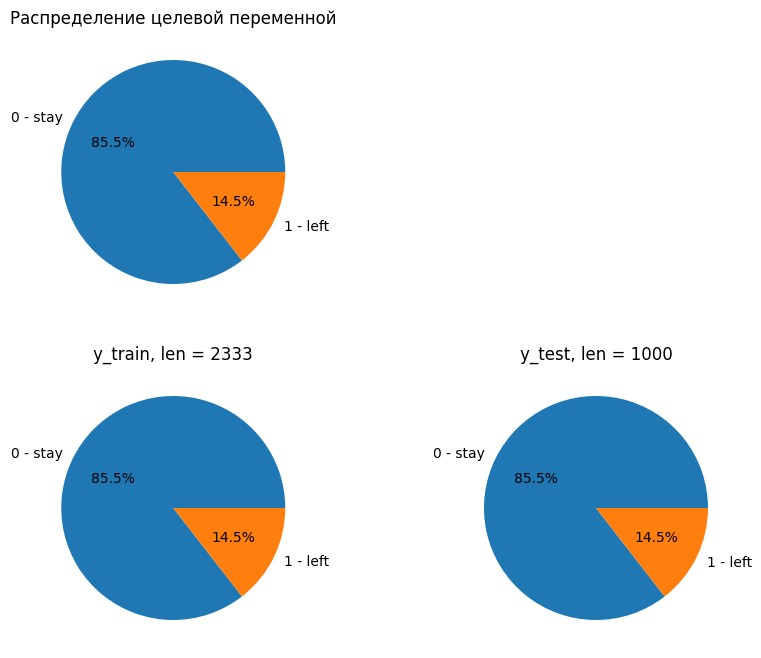

In [90]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.pie(y.value_counts(), labels=['0 - stay', '1 - left'], autopct='%1.1f%%')
plt.title("Распределение целевой переменной")

plt.subplot(2, 2, 3)
plt.pie(y_train.value_counts(), labels=['0 - stay', '1 - left'], autopct='%1.1f%%')
plt.title(f"y_train, len = {len(y_train)}")

plt.subplot(2, 2, 4)
plt.pie(y_test.value_counts(), labels=['0 - stay', '1 - left'], autopct='%1.1f%%')
plt.title(f"y_test, len = {len(y_test)}")
plt.show()

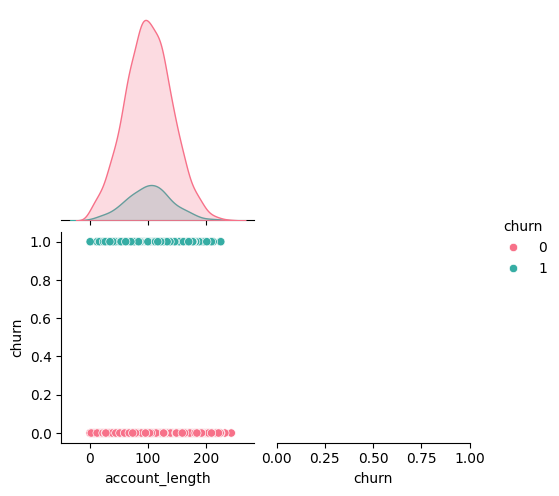

In [91]:
features_list = [
    'account_length',  # Длительность обслуживания клиента (в днях)
    # 'area_code',  # Код региона
    # 'international_plan',  # Наличие международного тарифа (1 — да, 0 — нет)
    # 'voice_mail_plan',  # Наличие голосовой почты (1 — да, 0 — нет)
    # 'number_vmail_messages',  # Количество сообщений голосовой почты
    # 'total_day_minutes',  # Общее количество минут разговоров днём
    # 'total_day_calls',  # Количество дневных звонков
    # 'total_day_charge',  # Стоимость дневных звонков
    # 'total_eve_minutes',  # Общее количество минут разговоров вечером
    # 'total_eve_calls',  # Количество вечерних звонков
    # 'total_eve_charge',  # Стоимость вечерних звонков
    # 'total_night_minutes',  # Общее количество минут разговоров ночью
    # 'total_night_calls',  # Количество ночных звонков
    # 'total_night_charge',  # Стоимость ночных звонков
    # 'total_intl_minutes',  # Общее количество международных минут
    # 'total_intl_calls',  # Количество международных звонков
    # 'total_intl_charge',  # Стоимость международных звонков
    # 'customer_service_calls',  # Количество обращений в службу поддержки
    'churn'  # Целевая переменная: факт оттока клиента (1 — ушёл, 0 — остался)
]

sns.pairplot(df, vars=features_list, hue="churn", palette="husl", corner=True)

plt.show()

## Обучение
### DecisionTreeClassifier
#### Стандарные параметры

In [106]:
model_clf = DecisionTreeClassifier(criterion='gini', random_state=random_id)
model_clf.fit(X_train, y_train)

y_pred = model_clf.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Score: {model_clf.score(X_test, y_test):.4f}')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'f1: {f1:.4f}')
model_clf

Score: 0.9190
Precision: 0.7051
Recall: 0.7586
f1: 0.7309


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

#### Поиск параметров

In [103]:
model_clf = DecisionTreeClassifier(random_state=random_id)
# Можно было и рандомгрид использовать, но мне просто было инетересно через GridSearchCV
param_grid = {
    'criterion': ['gini', 'log_loss'],
    'splitter': ['best'],
    'max_depth': [x for x in range(2, 10+1)],
    'min_samples_split': [2, 5, 10, 20] + [x for x in range(50, 200+1, 50)],
    'min_samples_leaf': [2, 5, 10, 20] + [x for x in range(50, 200+1, 50)],
    # 'min_weight_fraction_leaf': [],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    model_clf,
    param_grid,
    scoring='neg_mean_squared_error', #['precision', 'recall', 'f1'], #'precision', 'recall', ['metric1', 'metric2', ...]
    n_jobs=-1,
    # refit='recall',
    cv=5,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best params {best_params}")
print(f"Best model {best_model}")
print(f"{grid_search.best_score_:.4f}\n\n")



Best params {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'best'}
Best model DecisionTreeClassifier(max_depth=8, max_features='sqrt', min_samples_leaf=2,
                       min_samples_split=5, random_state=123)
-0.0960




In [104]:
y_pred = best_model.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Score: {best_model.score(X_test, y_test):.4f}')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'f1: {f1:.4f}')

Score: 0.8980
Precision: 0.7363
Recall: 0.4621
f1: 0.5678


Best params

1: {'criterion': 'gini', 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 20, 'splitter': 'best'}

2: {'criterion': 'gini', 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 20, 'splitter': 'best'}

In [105]:
model_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=13,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=20,
    splitter='best',
    random_state=random_id
)
model_clf.fit(X_train, y_train)

y_pred = model_clf.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Score: {model_clf.score(X_test, y_test):.4f}')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'f1: {f1:.4f}')

Score: 0.8980
Precision: 0.7529
Recall: 0.4414
f1: 0.5565


## RandomForestClassifier